      CustomerID  Count        Country       State          City  Zip Code  \
0     3668-QPYBK      1  United States  California   Los Angeles     90003   
1     9237-HQITU      1  United States  California   Los Angeles     90005   
2     9305-CDSKC      1  United States  California   Los Angeles     90006   
3     7892-POOKP      1  United States  California   Los Angeles     90010   
4     0280-XJGEX      1  United States  California   Los Angeles     90015   
...          ...    ...            ...         ...           ...       ...   
7038  2569-WGERO      1  United States  California       Landers     92285   
7039  6840-RESVB      1  United States  California      Adelanto     92301   
7040  2234-XADUH      1  United States  California         Amboy     92304   
7041  4801-JZAZL      1  United States  California  Angelus Oaks     92305   
7042  3186-AJIEK      1  United States  California  Apple Valley     92308   

                    Lat Long   Latitude   Longitude  Gender  ..

C:\Users\gandu\AppData\Local\Temp\ipykernel_28576\908905560.py:33: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gandu\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


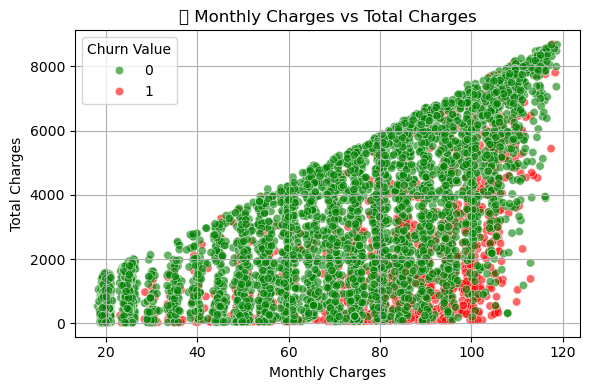

C:\Users\gandu\AppData\Local\Temp\ipykernel_28576\908905560.py:41: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gandu\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


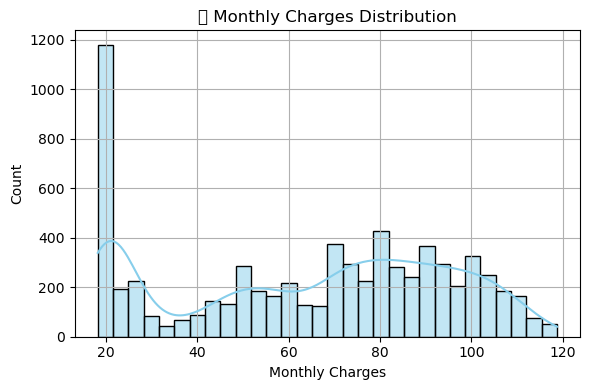

C:\Users\gandu\AppData\Local\Temp\ipykernel_28576\908905560.py:49: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gandu\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


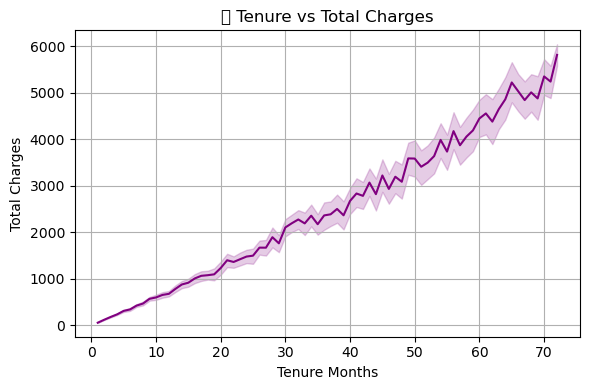


🔷 Linear Regression - MSE: 526947.73

🔶 Logistic Regression - Accuracy: 79.53%

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.93      0.87      1012
           1       0.71      0.46      0.56       395

    accuracy                           0.80      1407
   macro avg       0.76      0.69      0.71      1407
weighted avg       0.78      0.80      0.78      1407


📈 Predicted Total Charges: ₹1465.49
🔍 Predicted Churn: Yes


In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report

# Load dataset
df = pd.read_excel("C:\\Users\\gandu\\Desktop\\Telco_customer_churn.xlsx")

print(df)
# Clean and prepare data
df_clean = df[['Monthly Charges', 'Total Charges', 'Churn Value', 'Gender', 'Senior Citizen', 'Tenure Months']].copy()
df_clean = df_clean[df_clean['Total Charges'] != ' ']  # Remove rows with empty Total Charges
df_clean['Total Charges'] = pd.to_numeric(df_clean['Total Charges'])
df_clean['Gender'] = LabelEncoder().fit_transform(df_clean['Gender'])  # Male=1, Female=0

# -------------------------
# 🔵 SCATTER PLOT
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=df_clean,
    x='Monthly Charges',
    y='Total Charges',
    hue='Churn Value',
    palette={0: 'green', 1: 'red'},
    alpha=0.6
)
plt.title('🎯 Monthly Charges vs Total Charges')
plt.grid(True)
plt.tight_layout()
plt.show()

# 🟡 HISTOGRAM
plt.figure(figsize=(6, 4))
sns.histplot(df_clean['Monthly Charges'], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title('📊 Monthly Charges Distribution')
plt.grid(True)
plt.tight_layout()
plt.show()

# 🔵 LINE PLOT
plt.figure(figsize=(6, 4))
sns.lineplot(data=df_clean, x='Tenure Months', y='Total Charges', color='purple')
plt.title('📈 Tenure vs Total Charges')
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------
# ML Models
X = df_clean[['Monthly Charges', 'Tenure Months', 'Gender']]
y_lin = df_clean['Total Charges']
y_log = df_clean['Churn Value']

# Linear Regression
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X, y_lin, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(X_train_lin, y_train_lin)
y_pred_lin = lr.predict(X_test_lin)
mse = mean_squared_error(y_test_lin, y_pred_lin)
print(f"\n🔷 Linear Regression - MSE: {mse:.2f}")

# Logistic Regression
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)
log = LogisticRegression(max_iter=1000)
log.fit(X_train_log, y_train_log)
y_pred_log = log.predict(X_test_log)
acc = accuracy_score(y_test_log, y_pred_log)
report = classification_report(y_test_log, y_pred_log)
print(f"\n🔶 Logistic Regression - Accuracy: {acc:.2%}")
print("\n📋 Classification Report:\n", report)

# -------------------------
# 🔮 Sample Prediction
sample = pd.DataFrame({
    'Monthly Charges': [90],
    'Tenure Months': [6],
    'Gender': [1]  # 1 = Male, 0 = Female
})

total_pred = lr.predict(sample)[0]
churn_pred = log.predict(sample)[0]
churn_status = "Yes" if churn_pred == 1 else "No"

print(f"\n📈 Predicted Total Charges: ₹{total_pred:.2f}")
print(f"🔍 Predicted Churn: {churn_status}")

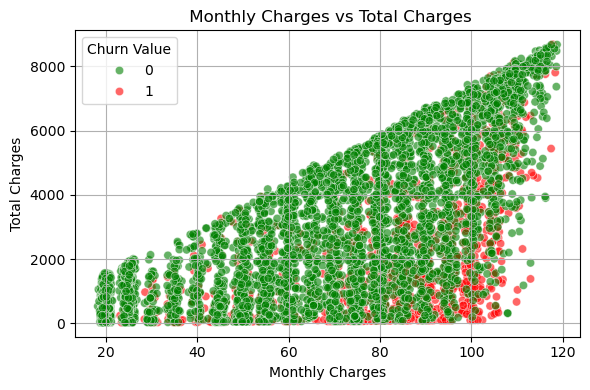

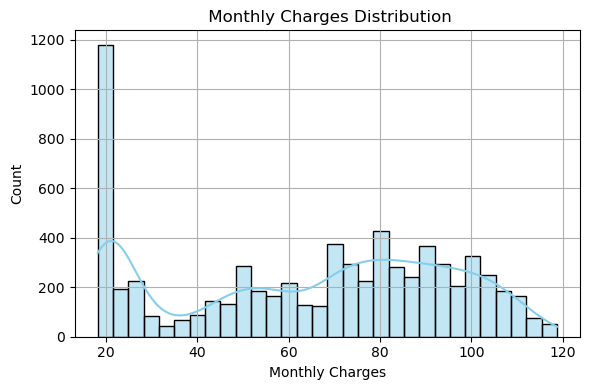

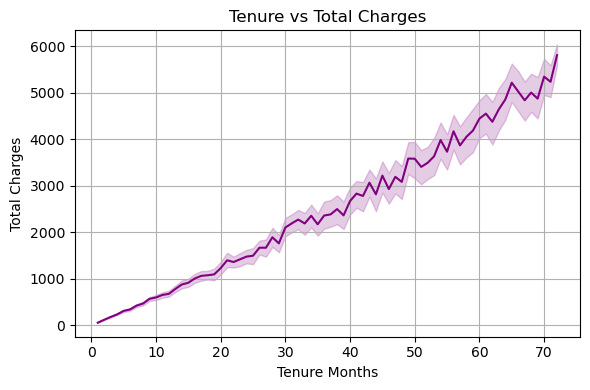


 Linear Regression - MSE: 526947.73

 Logistic Regression - Accuracy: 79.53%

 Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.93      0.87      1012
           1       0.71      0.46      0.56       395

    accuracy                           0.80      1407
   macro avg       0.76      0.69      0.71      1407
weighted avg       0.78      0.80      0.78      1407


📈 Predicted Total Charges: ₹1465.49
🔍 Predicted Churn: Yes


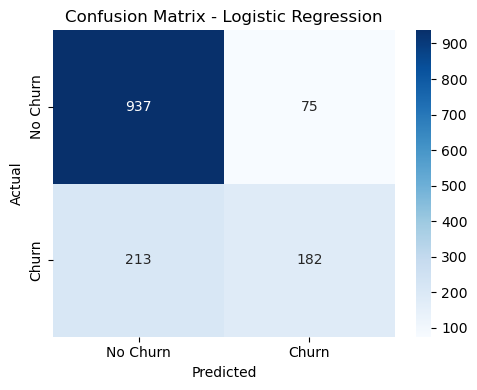

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report

# Load dataset
df = pd.read_excel("C:\\Users\\gandu\\Desktop\\Telco_customer_churn.xlsx")

# Clean and prepare data
df_clean = df[['Monthly Charges', 'Total Charges', 'Churn Value', 'Gender', 'Senior Citizen', 'Tenure Months']].copy()
df_clean = df_clean[df_clean['Total Charges'] != ' ']  # Remove rows with empty Total Charges
df_clean['Total Charges'] = pd.to_numeric(df_clean['Total Charges'])
df_clean['Gender'] = LabelEncoder().fit_transform(df_clean['Gender'])  # Male=1, Female=0

#SCATTER PLOT
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=df_clean,
    x='Monthly Charges',
    y='Total Charges',
    hue='Churn Value',
    palette={0: 'green', 1: 'red'},
    alpha=0.6
)
plt.title(' Monthly Charges vs Total Charges')
plt.grid(True)
plt.tight_layout()
plt.show()

#  HISTOGRAM
plt.figure(figsize=(6, 4))
sns.histplot(df_clean['Monthly Charges'], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(' Monthly Charges Distribution')
plt.grid(True)
plt.tight_layout()
plt.show()

#  LINE PLOT
plt.figure(figsize=(6, 4))
sns.lineplot(data=df_clean, x='Tenure Months', y='Total Charges', color='purple')
plt.title('Tenure vs Total Charges')
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------
# ML Models
X = df_clean[['Monthly Charges', 'Tenure Months', 'Gender']]
y_lin = df_clean['Total Charges']
y_log = df_clean['Churn Value']

# Linear Regression
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X, y_lin, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(X_train_lin, y_train_lin)
y_pred_lin = lr.predict(X_test_lin)
mse = mean_squared_error(y_test_lin, y_pred_lin)
print(f"\n Linear Regression - MSE: {mse:.2f}")

# Logistic Regression
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)
log = LogisticRegression(max_iter=1000)
log.fit(X_train_log, y_train_log)
y_pred_log = log.predict(X_test_log)
acc = accuracy_score(y_test_log, y_pred_log)
report = classification_report(y_test_log, y_pred_log)
print(f"\n Logistic Regression - Accuracy: {acc:.2%}")
print("\n Classification Report:\n", report)

# -------------------------
#  Sample Prediction
sample = pd.DataFrame({
    'Monthly Charges': [90],
    'Tenure Months': [6],
    'Gender': [1]  # 1 = Male, 0 = Female
})

total_pred = lr.predict(sample)[0]
churn_pred = log.predict(sample)[0]
churn_status = "Yes" if churn_pred == 1 else "No"

print(f"\n📈 Predicted Total Charges: ₹{total_pred:.2f}")
print(f"🔍 Predicted Churn: {churn_status}")

from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test_log, y_pred_log)

# Plotting
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()